<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 4</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Parsa Saeednia <br>
        <b>🆔 Student ID:</b> 810102460 <br><br>
        <h5 style="color: #1a365d;"> TASK 3 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 4 - Task 3. It tackles <b>Knowledge Tracing</b> using the ASSISTments2017 dataset. We model sequential student learning behaviors over time using <b>Recurrent Neural Networks (RNN)</b> and <b>LSTMs</b> to predict whether a student will answer the next question correctly.
</div>

##

## Table of Contents
1. [Data Exploration & Temporal Analysis](#exploration)
2. [Sequence Preprocessing & Padding](#preprocessing)
3. [RNN Architecture & Training](#modeling)
4. [Evaluation & LSTM Comparison](#evaluation)

<a id="exploration"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Data Exploration & Temporal Analysis</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We analyze chronological student interactions to understand correctness patterns, skill difficulties, and correlations between help-seeking behaviors (hints, time taken) and future success.
</div>

##

### 1.1 Importing Analytical Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### 1.2 Loading & Inspecting the Dataset

In [2]:
df = pd.read_csv('data/assistments2017.csv')

display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 85132 entries, 0 to 85131
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   studentId               85132 non-null  int64  
 1   skill                   85132 non-null  str    
 2   problemType             85132 non-null  str    
 3   startTime               85132 non-null  str    
 4   timeTaken               85132 non-null  float64
 5   correct                 85132 non-null  int64  
 6   hintCount               85132 non-null  int64  
 7   attemptCount            85132 non-null  int64  
 8   frPast5WrongCount       85132 non-null  int64  
 9   responseIsFillIn        85132 non-null  int64  
 10  responseIsChosen        85132 non-null  int64  
 11  consecutiveErrorsInRow  85132 non-null  int64  
dtypes: float64(1), int64(8), str(3)
memory usage: 7.8 MB


None

,studentId,skill,problemType,startTime,timeTaken,correct,hintCount,attemptCount,frPast5WrongCount,responseIsFillIn,responseIsChosen,consecutiveErrorsInRow
0,8,perimeter,textfieldquestion,2005-05-09 13:55:03,67.0,0,1,1,0,0,0,0
1,8,perimeter,textfieldquestion,2005-05-09 13:56:10,5.0,0,2,2,0,0,0,0
2,8,perimeter,textfieldquestion,2005-05-09 13:56:15,14.0,1,2,3,0,0,0,0
3,8,area,radioquestion,2005-05-09 13:56:29,17.0,1,0,1,1,0,0,0
4,8,area,textfieldquestion,2005-05-09 13:56:46,13.0,0,1,1,1,0,0,0


### 1.3 Sequence Length Distribution

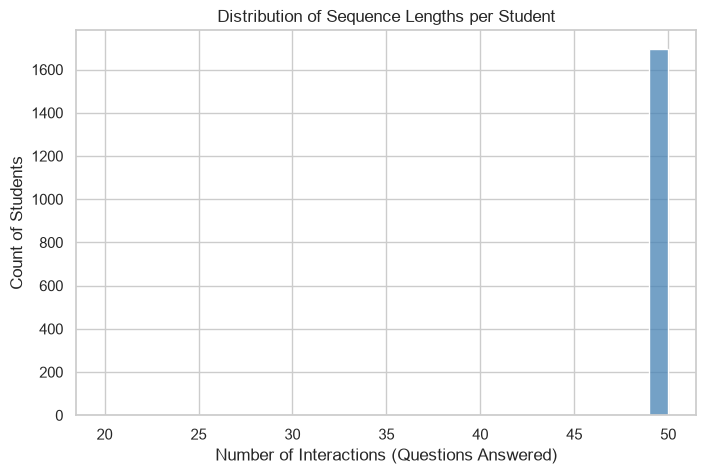

count    1705.000000
mean       49.930792
std         1.174313
min        20.000000
25%        50.000000
50%        50.000000
75%        50.000000
max        50.000000
dtype: float64

In [3]:
sequence_lengths = df.groupby('studentId').size()

plt.figure(figsize=(8, 5))
sns.histplot(sequence_lengths, bins=30, color='steelblue')
plt.title('Distribution of Sequence Lengths per Student')
plt.xlabel('Number of Interactions (Questions Answered)')
plt.ylabel('Count of Students')
plt.show()

display(sequence_lengths.describe())

### 1.4 Global Correctness Imbalance

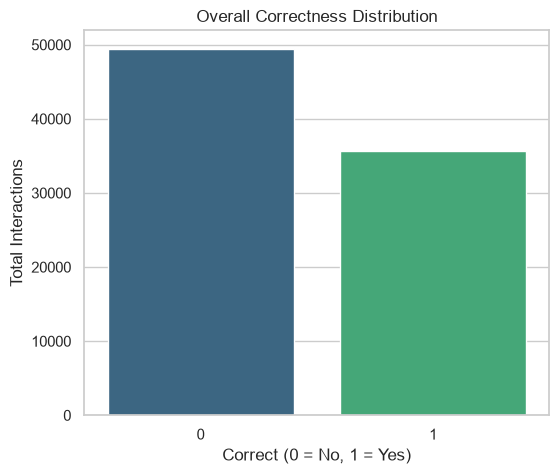

correct
0    58.117981
1    41.882019
Name: proportion, dtype: float64

In [4]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='correct', hue='correct', palette='viridis', legend=False)
plt.title('Overall Correctness Distribution')
plt.xlabel('Correct (0 = No, 1 = Yes)')
plt.ylabel('Total Interactions')
plt.show()

display(df['correct'].value_counts(normalize=True) * 100)

### 1.5 Student Ability vs. Help-Seeking Behaviors

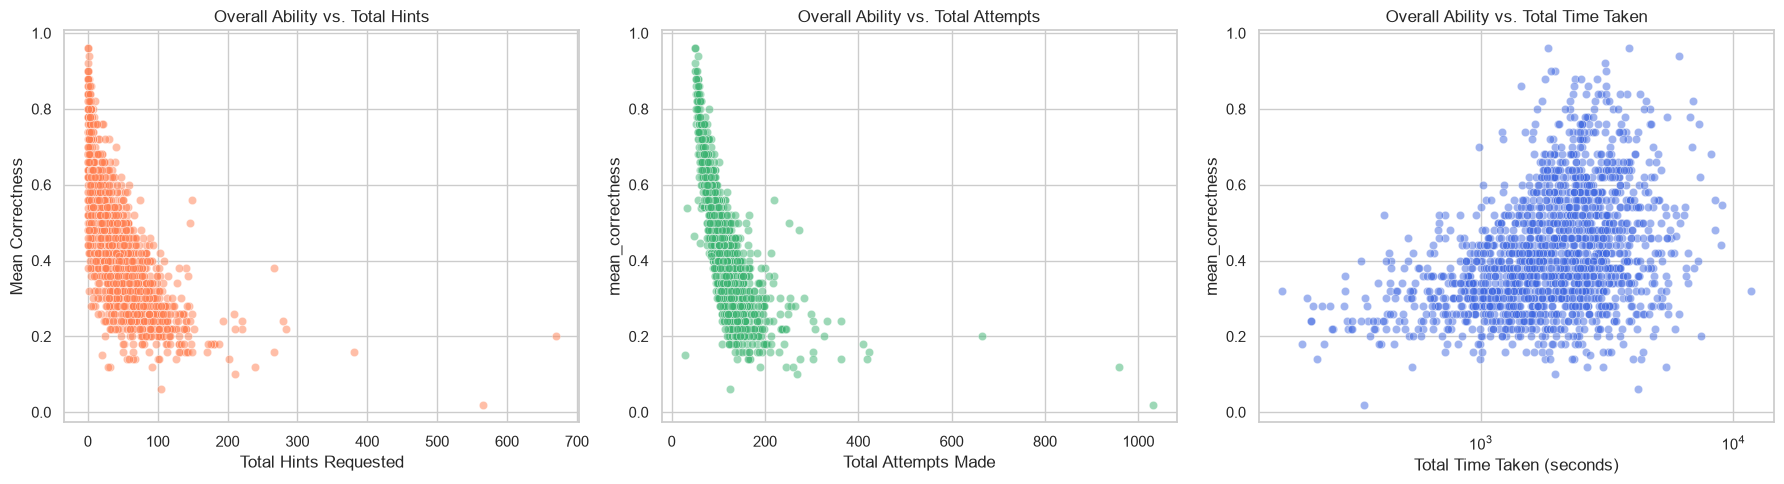

In [5]:
student_ability = df.groupby('studentId').agg(
    mean_correctness=('correct', 'mean'),
    total_time=('timeTaken', 'sum'),
    total_hints=('hintCount', 'sum'),
    total_attempts=('attemptCount', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=student_ability, x='total_hints', y='mean_correctness', ax=axes[0], alpha=0.5, color='coral')
axes[0].set_title('Overall Ability vs. Total Hints')
axes[0].set_xlabel('Total Hints Requested')
axes[0].set_ylabel('Mean Correctness')

sns.scatterplot(data=student_ability, x='total_attempts', y='mean_correctness', ax=axes[1], alpha=0.5, color='mediumseagreen')
axes[1].set_title('Overall Ability vs. Total Attempts')
axes[1].set_xlabel('Total Attempts Made')

sns.scatterplot(data=student_ability, x='total_time', y='mean_correctness', ax=axes[2], alpha=0.5, color='royalblue')
axes[2].set_title('Overall Ability vs. Total Time Taken')
axes[2].set_xlabel('Total Time Taken (seconds)')
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()

### 1.6 Correlation Analysis: Past Struggles vs. Future Performance

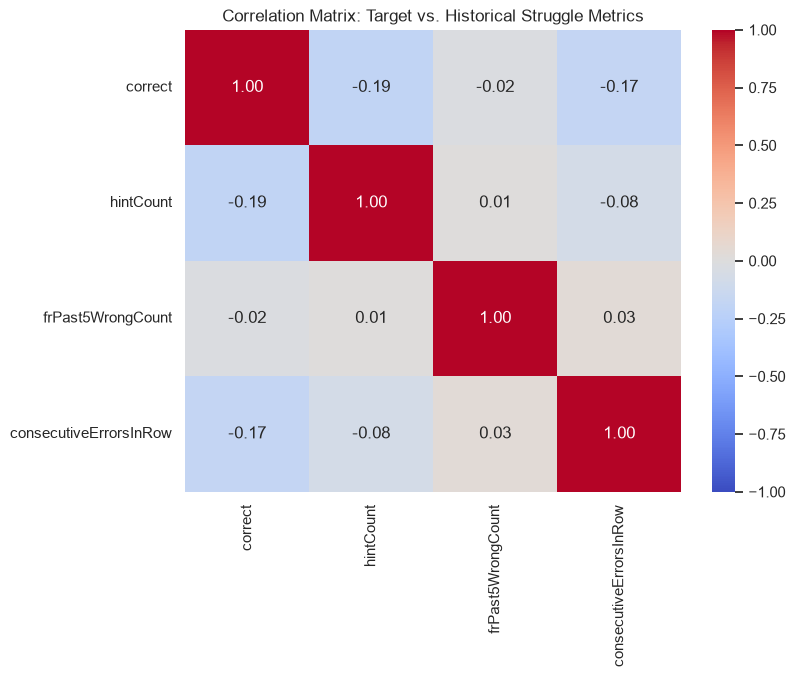

In [6]:
focus_features = ['correct', 'hintCount', 'frPast5WrongCount', 'consecutiveErrorsInRow']
corr_matrix = df[focus_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: Target vs. Historical Struggle Metrics')
plt.show()

### 1.7 Visualizing Correctness by Skill & Problem Type

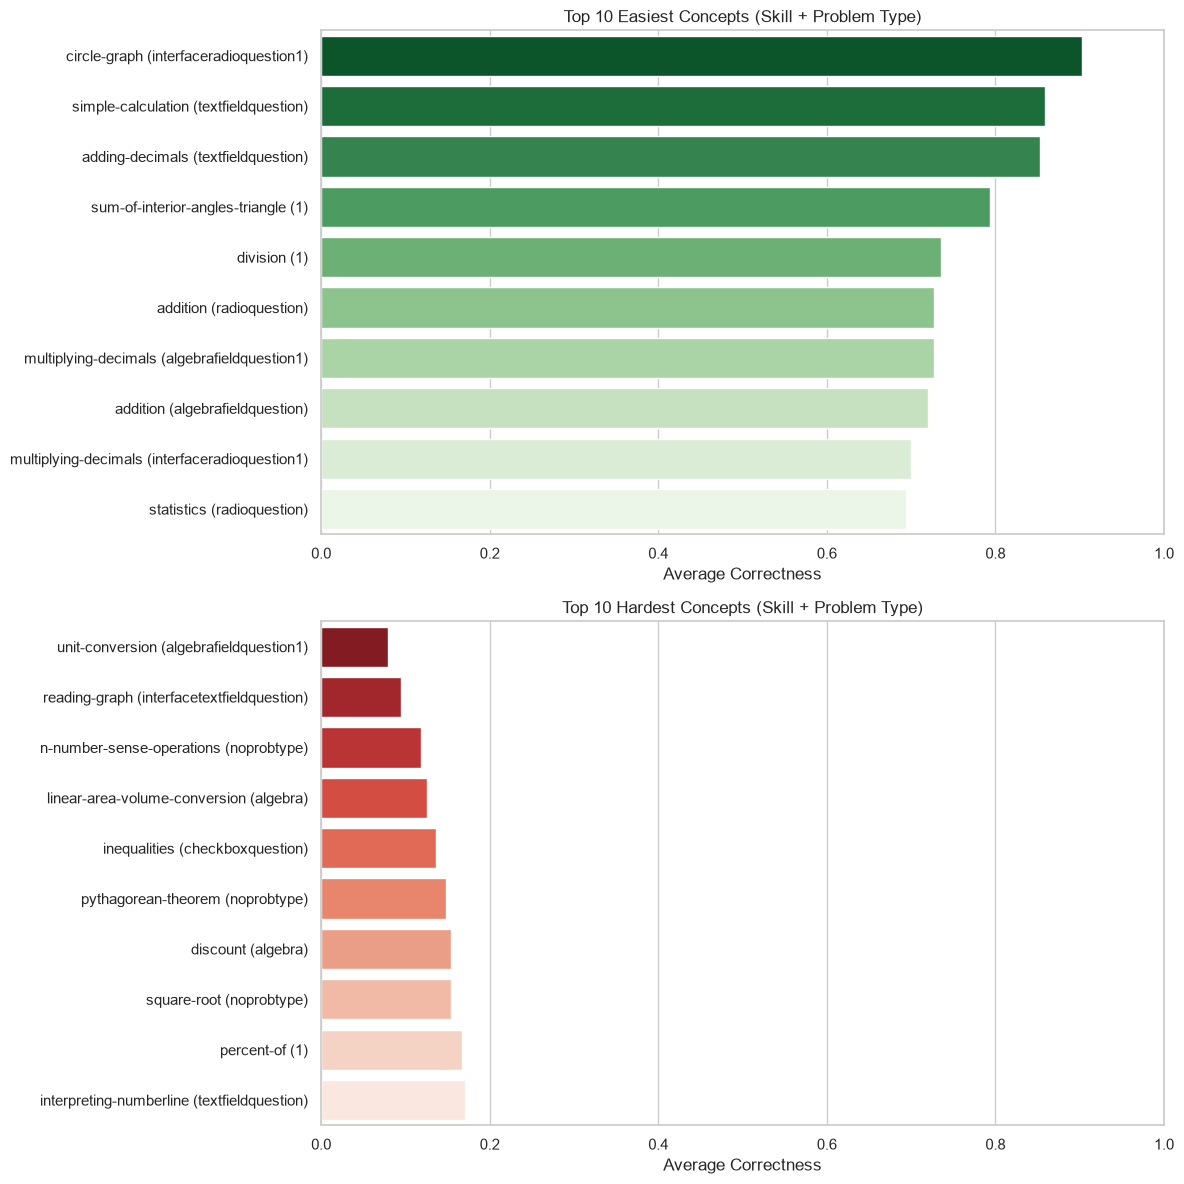

In [7]:
df['skill_problem'] = df['skill'] + " (" + df['problemType'] + ")"

combo_stats = df.groupby('skill_problem').agg(
    total_attempts=('correct', 'count'),
    avg_correct=('correct', 'mean')
).reset_index()

combo_stats = combo_stats[combo_stats['total_attempts'] > 30]

top_10_easiest = combo_stats.nlargest(10, 'avg_correct')
top_10_hardest = combo_stats.nsmallest(10, 'avg_correct')

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.barplot(data=top_10_easiest, x='avg_correct', y='skill_problem', ax=axes[0], palette='Greens_r', hue='skill_problem', legend=False)
axes[0].set_title('Top 10 Easiest Concepts (Skill + Problem Type)')
axes[0].set_xlabel('Average Correctness')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1)

sns.barplot(data=top_10_hardest, x='avg_correct', y='skill_problem', ax=axes[1], palette='Reds_r', hue='skill_problem', legend=False)
axes[1].set_title('Top 10 Hardest Concepts (Skill + Problem Type)')
axes[1].set_xlabel('Average Correctness')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### 1.8 The Forgetting Curve: Analyzing Time Lags Between Interactions

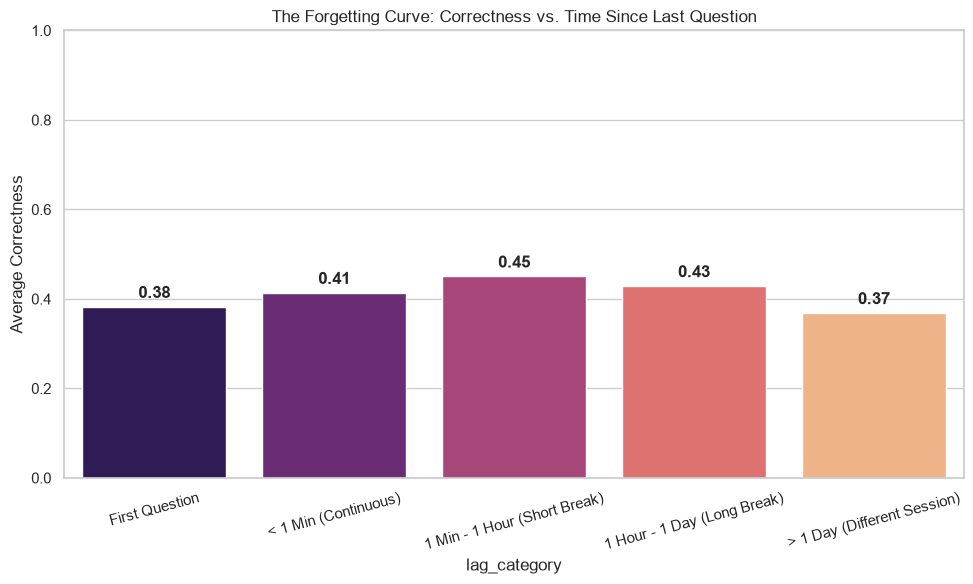

In [8]:
df['startTime'] = pd.to_datetime(df['startTime'])
df = df.sort_values(by=['studentId', 'startTime'])

df['time_lag_seconds'] = df.groupby('studentId')['startTime'].diff().dt.total_seconds()
df['time_lag_seconds'] = df['time_lag_seconds'].fillna(0)

def categorize_lag(seconds):
    if seconds == 0: return 'First Question'
    elif seconds < 60: return '< 1 Min (Continuous)'
    elif seconds < 3600: return '1 Min - 1 Hour (Short Break)'
    elif seconds < 86400: return '1 Hour - 1 Day (Long Break)'
    else: return '> 1 Day (Different Session)'

df['lag_category'] = df['time_lag_seconds'].apply(categorize_lag)

lag_stats = df.groupby('lag_category')['correct'].mean().reindex([
    'First Question', '< 1 Min (Continuous)', '1 Min - 1 Hour (Short Break)',
    '1 Hour - 1 Day (Long Break)', '> 1 Day (Different Session)'
])

plt.figure(figsize=(10, 6))
sns.barplot(x=lag_stats.index, y=lag_stats.values, palette='magma', hue=lag_stats.index, legend=False)
plt.title('The Forgetting Curve: Correctness vs. Time Since Last Question')
plt.ylabel('Average Correctness')
plt.ylim(0, 1)
plt.xticks(rotation=15)

for i, v in enumerate(lag_stats.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 1.9 Temporal Dynamics: First 10 vs. Last 10 Interactions

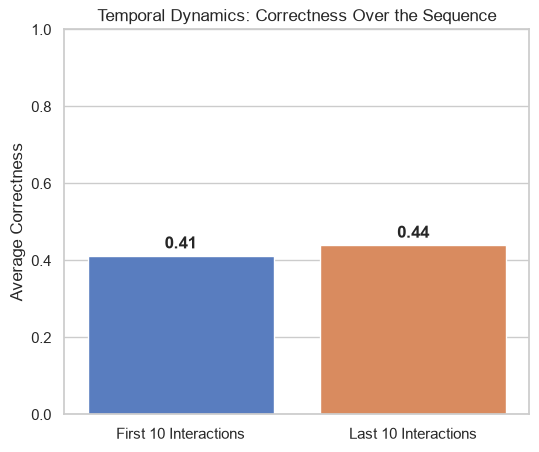

In [9]:
df['interaction_num'] = df.groupby('studentId').cumcount() + 1

first_10 = df[df['interaction_num'] <= 10]['correct'].mean()
last_10 = df[(df['interaction_num'] > 40) & (df['interaction_num'] <= 50)]['correct'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=['First 10 Interactions', 'Last 10 Interactions'], y=[first_10, last_10], palette='muted', hue=['First 10 Interactions', 'Last 10 Interactions'], legend=False)
plt.title('Temporal Dynamics: Correctness Over the Sequence')
plt.ylabel('Average Correctness')
plt.ylim(0, 1)

for i, v in enumerate([first_10, last_10]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

### 1.10 Analysis of Question Formats: Fill-in vs. Multiple Choice

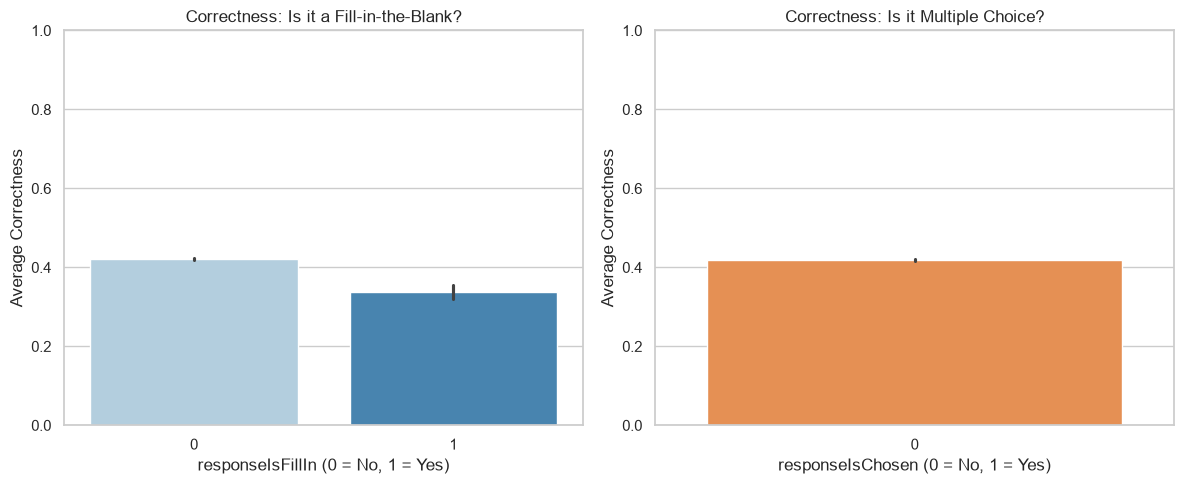

,"Fill-In (1=Yes, 0=No)","Chosen (1=Yes, 0=No)"
0,0.421646,0.41882
1,0.338189,NaN


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='responseIsFillIn', y='correct', ax=axes[0], palette='Blues', hue='responseIsFillIn', legend=False)
axes[0].set_title('Correctness: Is it a Fill-in-the-Blank?')
axes[0].set_xlabel('responseIsFillIn (0 = No, 1 = Yes)')
axes[0].set_ylabel('Average Correctness')
axes[0].set_ylim(0, 1)

sns.barplot(data=df, x='responseIsChosen', y='correct', ax=axes[1], palette='Oranges', hue='responseIsChosen', legend=False)
axes[1].set_title('Correctness: Is it Multiple Choice?')
axes[1].set_xlabel('responseIsChosen (0 = No, 1 = Yes)')
axes[1].set_ylabel('Average Correctness')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'Fill-In (1=Yes, 0=No)': df.groupby('responseIsFillIn')['correct'].mean(),
    'Chosen (1=Yes, 0=No)': df.groupby('responseIsChosen')['correct'].mean()
}))

### 1.11 Final Sanity Checks: Multicollinearity & Rare Skills

In [11]:
print("MULTICOLLINEARITY CHECK :")
features_to_check = ['hintCount', 'attemptCount', 'consecutiveErrorsInRow', 'timeTaken', 'time_lag_seconds']
display(df[features_to_check].corr().round(2))

print("\nRARE SKILLS CHECK :\n")
df['skill_problem'] = df['skill'] + "_" + df['problemType']
skill_counts = df['skill_problem'].value_counts()

total_skills = len(skill_counts)
rare_skills_under_10 = len(skill_counts[skill_counts < 10])
rare_skills_under_5 = len(skill_counts[skill_counts < 5])

print(f"Total Unique Skill-Problem Combos: {total_skills}")
print(f"Combos appearing fewer than 10 times: {rare_skills_under_10} ({(rare_skills_under_10/total_skills)*100:.1f}%)")
print(f"Combos appearing fewer than 5 times: {rare_skills_under_5} ({(rare_skills_under_5/total_skills)*100:.1f}%)")

print("\nBottom 5 Rarest Combos:")
print(skill_counts.tail(5))

MULTICOLLINEARITY CHECK :


,hintCount,attemptCount,consecutiveErrorsInRow,timeTaken,time_lag_seconds
hintCount,1.00,0.72,-0.08,-0.10,-0.04
attemptCount,0.72,1.00,0.27,-0.10,-0.05
consecutiveErrorsInRow,-0.08,0.27,1.00,-0.00,0.00
timeTaken,-0.10,-0.10,-0.00,1.00,0.09
time_lag_seconds,-0.04,-0.05,0.00,0.09,1.00



RARE SKILLS CHECK :

Total Unique Skill-Problem Combos: 418
Combos appearing fewer than 10 times: 40 (9.6%)
Combos appearing fewer than 5 times: 17 (4.1%)

Bottom 5 Rarest Combos:
skill_problem
p-patterns-relations-algebra_algebra    1
comparing-fractions_other               1
fraction-multiplication_other           1
multiplying-decimals_algebra            1
square-root_algebrafieldquestion        1
Name: count, dtype: int64


<a id="preprocessing"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Dynamic Preprocessing & Feature Engineering</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> Because we are tuning the <code>rare_skill_threshold</code>, the size of our vocabulary and embedding layers will change per model. We build atomic functions to dynamically prune, encode, and shift (anti-leakage) the data on the fly.
</div>

##

### 2.1 Core Imports

In [12]:
import copy
import time
import torch
import random
import torch.nn as nn
import torch.optim as optim
import itertools
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score

### 2.2 Dynamic Feature Pruning & Encoding

In [13]:
def process_features(dataframe, rare_threshold, use_time_lag, use_fill_in):
    temp_df = dataframe.copy()
    temp_df['skill_problem'] = temp_df['skill'] + "_" + temp_df['problemType']
    
    skill_counts = temp_df['skill_problem'].value_counts()
    rare_skills = skill_counts[skill_counts < rare_threshold].index
    temp_df.loc[temp_df['skill_problem'].isin(rare_skills), 'skill_problem'] = '[RARE_SKILL]'
    
    le = LabelEncoder()
    temp_df['skill_problem_encoded'] = le.fit_transform(temp_df['skill_problem']) + 1
    num_classes = len(le.classes_) + 1 
    
    temp_continuous = ['hintCount', 'attemptCount', 'consecutiveErrorsInRow']
    if use_time_lag: temp_continuous.append('time_lag_seconds')
    if use_fill_in: temp_continuous.append('responseIsFillIn')
    
    scaler = StandardScaler()
    temp_df[temp_continuous] = scaler.fit_transform(temp_df[temp_continuous])
    
    return temp_df, num_classes, temp_continuous

### 2.3 Temporal Anti-Leakage & Tensor Padding Engine

In [14]:
def build_sequence_tensors(processed_df, continuous_features):
    student_groups = processed_df.groupby('studentId')
    
    X_cat_list = []
    X_cont_list = []
    y_targets = []
    
    for student_id, group in student_groups:
        group = group.sort_values('startTime')
        
        cat_seq = torch.tensor(group['skill_problem_encoded'].values, dtype=torch.long)
        target_seq = torch.tensor(group['correct'].values, dtype=torch.float32)
        
        cont_seq = torch.tensor(group[continuous_features].values, dtype=torch.float32)
        shifted_cont = torch.zeros_like(cont_seq)
        shifted_cont[1:] = cont_seq[:-1]
        
        X_cat_list.append(cat_seq)
        X_cont_list.append(shifted_cont)
        y_targets.append(target_seq)
        
    X_cat_padded = pad_sequence(X_cat_list, batch_first=True, padding_value=0)
    X_cont_padded = pad_sequence(X_cont_list, batch_first=True, padding_value=0.0)
    y_padded = pad_sequence(y_targets, batch_first=True, padding_value=-1.0)
    
    return X_cat_padded, X_cont_padded, y_padded

### 2.4 Unified Pipeline Wrapper

In [15]:
def build_tensors_for_config(dataframe, cfg):
    processed_df, num_classes, cont_features = process_features(
        dataframe, 
        cfg['rare_skill_threshold'], 
        cfg['use_time_lag'], 
        cfg['use_fill_in']
    )
    
    X_cat, X_cont, y = build_sequence_tensors(processed_df, cont_features)
    
    return X_cat, X_cont, y, num_classes, len(cont_features)

<a id="modeling"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. RNN Architecture & Hyperparameter Grid Search</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We define our dataloaders, RNN architecture, and training components in atomic units to facilitate an automated grid search across the hyperparameter space.
</div>

##

### 3.1 Custom Dataset & DataLoader Generation

In [16]:
class KTDataset(Dataset):
    def __init__(self, X_cat, X_cont, y, window_size):
        self.X_cat = X_cat[:, -window_size:]
        self.X_cont = X_cont[:, -window_size:, :]
        self.y = y[:, -window_size:]
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X_cat[idx], self.X_cont[idx], self.y[idx]

def create_dataloaders(X_cat, X_cont, y, window_size, batch_size):
    indices = np.arange(len(y))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_ds = KTDataset(X_cat[train_idx], X_cont[train_idx], y[train_idx], window_size)
    val_ds = KTDataset(X_cat[val_idx], X_cont[val_idx], y[val_idx], window_size)
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)

### 3.2 Knowledge Tracing RNN Architecture

In [17]:
class KnowledgeTracingRNN(nn.Module):
    def __init__(self, num_skills, embed_dim, continuous_dim, hidden_dim, num_layers=1, dropout=0.2):
        super(KnowledgeTracingRNN, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=num_skills, embedding_dim=embed_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=embed_dim + continuous_dim, hidden_size=hidden_dim, 
                          num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(), nn.Linear(hidden_dim // 2, 1), nn.Sigmoid()
        )
    def forward(self, x_cat, x_cont):
        embedded_skills = self.embedding(x_cat)
        combined_input = torch.cat([embedded_skills, x_cont], dim=-1)
        rnn_out, _ = self.rnn(combined_input)
        return self.fc(rnn_out).squeeze(-1)

### 3.3 Training & Evaluation Core

In [18]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for x_cat, x_cont, y in dataloader:
        optimizer.zero_grad()
        preds = model(x_cat, x_cont)
        mask = (y != -1.0)
        if len(y[mask]) == 0: continue
        loss = criterion(preds[mask], y[mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y[mask])
    return total_loss / len(dataloader.dataset)

def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_cat, x_cont, y in dataloader:
            preds = model(x_cat, x_cont)
            mask = (y != -1.0)
            if len(y[mask]) == 0: continue
            loss = criterion(preds[mask], y[mask])
            total_loss += loss.item() * len(y[mask])
            all_preds.extend(preds[mask].cpu().numpy())
            all_targets.extend(y[mask].cpu().numpy())
    auc = roc_auc_score(all_targets, all_preds)
    acc = np.mean((np.array(all_preds) >= 0.5).astype(int) == np.array(all_targets))
    return total_loss / len(dataloader.dataset), auc, acc

### 3.4 Early Stopping Controller

In [19]:
def run_training_loop(model, train_loader, val_loader, criterion, optimizer, max_epochs=30, patience=4, verbose=False):
    best_val_loss = float('inf')
    best_auc = 0
    patience_counter = 0
    epochs_run = 0
    
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []} 
    
    for epoch in range(max_epochs):
        epochs_run += 1
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_auc, _ = evaluate_model(model, val_loader, criterion)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        
        if verbose:
            print(f"    Epoch {epoch+1:02d}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_auc = val_auc
            patience_counter = 0 
        else:
            patience_counter += 1
        if patience_counter >= patience:
            if verbose: print("    >> Early stopping triggered.")
            break
            
    return best_auc, epochs_run - patience, history

### 3.5 Automated Grid Search Execution (Silent Top 5 Finder)

In [20]:
grid_parameters = {
    "rare_skill_threshold": [5, 10, 20],
    "window_size": [5, 20, 50],
    "num_layers": [1, 2],
    "hidden_dim": [64],
    "embed_dim": [32, 64],
    "batch_size": [32],
    "lr": [0.005],
    "dropout": [0.2, 0.3],
    "use_time_lag": [True, False],
    "use_fill_in": [False, True]
}

keys, values = zip(*grid_parameters.items())
all_experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

random.seed(42)
sampled_experiments = random.sample(all_experiments, len(all_experiments)) 

tuning_results = []

print(f"Running Silent Grid Search on {len(sampled_experiments)} Configurations: ")

for i, cfg in enumerate(sampled_experiments):
    start_time = time.time()
    set_seed(42)
    
    X_cat, X_cont, y, num_classes, cont_dim = build_tensors_for_config(df, cfg)
    train_loader, val_loader = create_dataloaders(X_cat, X_cont, y, cfg['window_size'], cfg['batch_size'])
    
    model = KnowledgeTracingRNN(
        num_skills=num_classes, embed_dim=cfg['embed_dim'], continuous_dim=cont_dim, 
        hidden_dim=cfg['hidden_dim'], num_layers=cfg['num_layers'], dropout=cfg['dropout']
    )
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    
    best_auc, peak_epoch, _ = run_training_loop(model, train_loader, val_loader, criterion, optimizer, verbose=False)    
    
    cfg['AUC'] = best_auc
    cfg['Peak_Epoch'] = peak_epoch
    cfg['Time'] = round(time.time() - start_time, 1)
    tuning_results.append(cfg)
    
    print(f"[{i+1:03d}/{len(sampled_experiments):03d}] Thr:{cfg['rare_skill_threshold']:02d} | Win:{cfg['window_size']:02d} | Lyr:{cfg['num_layers']} | Hid:{cfg['hidden_dim']:03d} | Emb:{cfg['embed_dim']:02d} | BS:{cfg['batch_size']} | LR:{cfg['lr']:.4f} | Drop:{cfg['dropout']:.1f} | Lag:{str(cfg['use_time_lag'])[0]} | Fill:{str(cfg['use_fill_in'])[0]} --> AUC: {best_auc:.4f}")

top_5_models = sorted(tuning_results, key=lambda x: x['AUC'], reverse=True)[:5]
print("\n>> Top 5 Models Saved for Verbose Analysis.")

Running Silent Grid Search on 288 Configurations: 


/mnt/d/University/6th Semester/Data Science/Computer Assignments/UT-DataScience-Spring2026/Assignments/CA4/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


[001/288] Thr:05 | Win:20 | Lyr:2 | Hid:064 | Emb:64 | BS:32 | LR:0.0050 | Drop:0.2 | Lag:T | Fill:T --> AUC: 0.6729
[002/288] Thr:05 | Win:05 | Lyr:1 | Hid:064 | Emb:64 | BS:32 | LR:0.0050 | Drop:0.3 | Lag:T | Fill:F --> AUC: 0.6274
[003/288] Thr:10 | Win:20 | Lyr:1 | Hid:064 | Emb:64 | BS:32 | LR:0.0050 | Drop:0.3 | Lag:T | Fill:F --> AUC: 0.6719
[004/288] Thr:10 | Win:05 | Lyr:2 | Hid:064 | Emb:64 | BS:32 | LR:0.0050 | Drop:0.3 | Lag:T | Fill:T --> AUC: 0.6333
[005/288] Thr:10 | Win:05 | Lyr:2 | Hid:064 | Emb:32 | BS:32 | LR:0.0050 | Drop:0.2 | Lag:F | Fill:F --> AUC: 0.6273
[006/288] Thr:05 | Win:50 | Lyr:1 | Hid:064 | Emb:32 | BS:32 | LR:0.0050 | Drop:0.3 | Lag:F | Fill:T --> AUC: 0.6941
[007/288] Thr:05 | Win:20 | Lyr:2 | Hid:064 | Emb:32 | BS:32 | LR:0.0050 | Drop:0.3 | Lag:T | Fill:F --> AUC: 0.6755
[008/288] Thr:20 | Win:50 | Lyr:2 | Hid:064 | Emb:32 | BS:32 | LR:0.0050 | Drop:0.3 | Lag:F | Fill:T --> AUC: 0.7012
[009/288] Thr:05 | Win:20 | Lyr:1 | Hid:064 | Emb:64 | BS:32 | L

### 3.6 Deep Dive: Verbose Execution of the Top 5 Models

In [21]:
trained_top_models = []

for i, cfg in enumerate(top_5_models):
    print(f"\n>> Rank #{i+1} Model Details:")
    print(f"   [Threshold: {cfg['rare_skill_threshold']} | Window: {cfg['window_size']} | Layers: {cfg['num_layers']} | Hidden: {cfg['hidden_dim']} | Embed: {cfg['embed_dim']} | Batch: {cfg['batch_size']} | Drop: {cfg['dropout']} | LR: {cfg['lr']} | Lag: {cfg['use_time_lag']} | Fill: {cfg['use_fill_in']}]")
    print("-" * 105)
    
    set_seed(42)
    X_cat, X_cont, y, num_classes, cont_dim = build_tensors_for_config(df, cfg)
    train_loader, val_loader = create_dataloaders(X_cat, X_cont, y, cfg['window_size'], cfg['batch_size'])
    
    model = KnowledgeTracingRNN(
        num_skills=num_classes, embed_dim=cfg['embed_dim'], continuous_dim=cont_dim, 
        hidden_dim=cfg['hidden_dim'], num_layers=cfg['num_layers'], dropout=cfg['dropout']
    )
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    
    _, _, history = run_training_loop(model, train_loader, val_loader, criterion, optimizer, verbose=True)
    
    trained_top_models.append({
        'config': cfg,
        'model': model,
        'val_loader': val_loader,
        'num_classes': num_classes,
        'cont_dim': cont_dim,
        'history': history
    })


>> Rank #1 Model Details:
   [Threshold: 20 | Window: 50 | Layers: 2 | Hidden: 64 | Embed: 32 | Batch: 32 | Drop: 0.2 | LR: 0.005 | Lag: True | Fill: False]
---------------------------------------------------------------------------------------------------------
    Epoch 01/30 | Train Loss: 33.3371 | Val Loss: 32.7324 | Val AUC: 0.6268
    Epoch 02/30 | Train Loss: 32.7402 | Val Loss: 32.4103 | Val AUC: 0.6362
    Epoch 03/30 | Train Loss: 32.3965 | Val Loss: 32.1368 | Val AUC: 0.6529
    Epoch 04/30 | Train Loss: 32.0550 | Val Loss: 31.7662 | Val AUC: 0.6658
    Epoch 05/30 | Train Loss: 31.8599 | Val Loss: 31.7227 | Val AUC: 0.6645
    Epoch 06/30 | Train Loss: 31.5624 | Val Loss: 31.4847 | Val AUC: 0.6766
    Epoch 07/30 | Train Loss: 31.4445 | Val Loss: 31.4408 | Val AUC: 0.6819
    Epoch 08/30 | Train Loss: 31.1777 | Val Loss: 31.3226 | Val AUC: 0.6845
    Epoch 09/30 | Train Loss: 30.9945 | Val Loss: 31.1379 | Val AUC: 0.6882
    Epoch 10/30 | Train Loss: 30.9167 | Val Loss: 31

<a id="evaluation"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Evaluation & LSTM Comparison</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In accordance with Part 6, we thoroughly evaluate our optimal RNN architecture by analyzing its convergence curves, classification metrics, and qualitative prediction limitations. Finally, in Part 7, we implement an LSTM to evaluate how gated memory architectures compare against standard recurrent layers.
</div>

##

### 4.1 Multi-Model Inference Gathering


In [22]:
from sklearn.metrics import roc_curve, confusion_matrix, classification_report, roc_auc_score

roc_data = []
best_preds, best_targets = [], []

for i, entry in enumerate(trained_top_models):
    model = entry['model']
    val_loader = entry['val_loader']
    
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for x_cat, x_cont, targets in val_loader:
            preds = model(x_cat, x_cont)
            mask = (targets != -1.0)
            if len(targets[mask]) > 0:
                all_preds.extend(preds[mask].cpu().numpy())
                all_targets.extend(targets[mask].cpu().numpy())
    
    auc = roc_auc_score(all_targets, all_preds)
    fpr, tpr, _ = roc_curve(all_targets, all_preds)
    roc_data.append({'fpr': fpr, 'tpr': tpr, 'auc': auc, 'rank': i+1})
    
    if i == 0:
        best_preds, best_targets = all_preds, all_targets

### 4.2 Baseline Visualizations (ROC & Confusion Matrix)

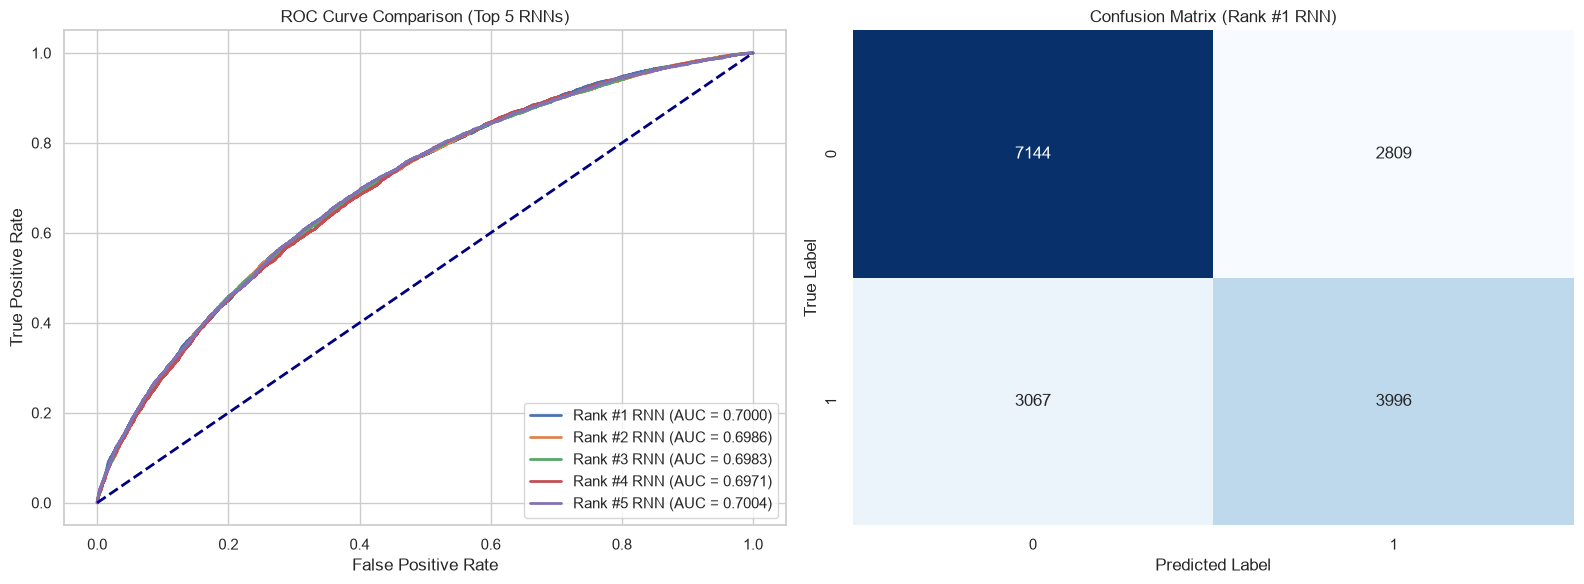

Classification Report for Rank #1 RNN:
              precision    recall  f1-score   support

         0.0       0.70      0.72      0.71      9953
         1.0       0.59      0.57      0.58      7063

    accuracy                           0.65     17016
   macro avg       0.64      0.64      0.64     17016
weighted avg       0.65      0.65      0.65     17016



In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for data in roc_data:
    axes[0].plot(data['fpr'], data['tpr'], lw=2, label=f"Rank #{data['rank']} RNN (AUC = {data['auc']:.4f})")

axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison (Top 5 RNNs)')
axes[0].legend(loc="lower right")

binary_preds = (np.array(best_preds) >= 0.5).astype(int)
cm = confusion_matrix(best_targets, binary_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix (Rank #1 RNN)')

plt.tight_layout()
plt.show()

print("Classification Report for Rank #1 RNN:")
print(classification_report(best_targets, binary_preds))

### 4.3 RNN Training Curves (Convergence Analysis)

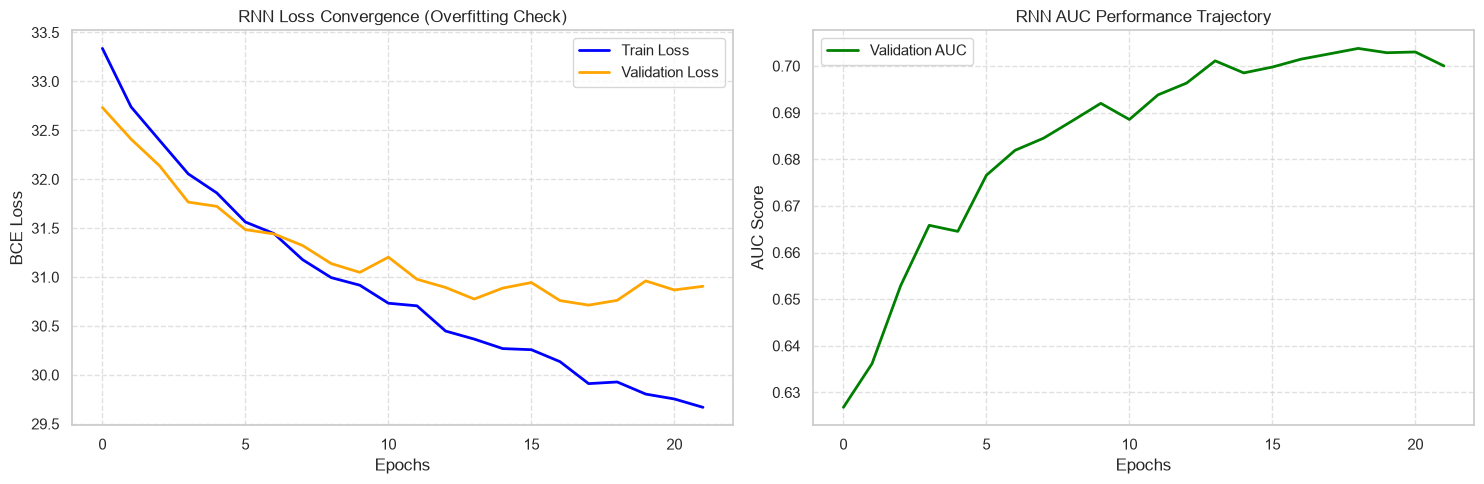

In [24]:
rnn_history = trained_top_models[0]['history']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(rnn_history['train_loss'], label='Train Loss', color='blue', lw=2)
axes[0].plot(rnn_history['val_loss'], label='Validation Loss', color='orange', lw=2)
axes[0].set_title('RNN Loss Convergence (Overfitting Check)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(rnn_history['val_auc'], label='Validation AUC', color='green', lw=2)
axes[1].set_title('RNN AUC Performance Trajectory')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('AUC Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 4.4 Qualitative Trajectory Analysis (RNN Predictions)

In [25]:
rank1_model = trained_top_models[0]['model']
rank1_val_loader = trained_top_models[0]['val_loader']

rank1_model.eval()
with torch.no_grad():
    for x_cat, x_cont, targets in rank1_val_loader:
        sample_preds = rank1_model(x_cat, x_cont)
        sample_x_cat, sample_x_cont, sample_targets = x_cat, x_cont, targets
        break 

sample_idx = 0
while sum(sample_targets[sample_idx] != -1.0) < 15:
    sample_idx += 1

mask = sample_targets[sample_idx] != -1.0
student_history = []

for t in range(sum(mask)):
    actual = int(sample_targets[sample_idx][mask][t].item())
    pred_prob = sample_preds[sample_idx][mask][t].item()
    pred_binary = 1 if pred_prob >= 0.5 else 0
    status = "✅ Correct" if actual == pred_binary else "❌ Incorrect"
    
    student_history.append({
        "Step": t + 1, "Skill_ID": int(sample_x_cat[sample_idx][mask][t].item()),
        "Hints (Scaled)": round(sample_x_cont[sample_idx][mask][t][0].item(), 2),
        "Actual Target": actual, "RNN Prob": f"{pred_prob:.2f}",
        "Prediction": pred_binary, "Status": status
    })

print(f"MICRO-ANALYSIS: STUDENT #{sample_idx} LONGITUDINAL TRAJECTORY (RNN)")
print(pd.DataFrame(student_history).to_string(index=False))

MICRO-ANALYSIS: STUDENT #0 LONGITUDINAL TRAJECTORY (RNN)
 Step  Skill_ID  Hints (Scaled)  Actual Target RNN Prob  Prediction      Status
    1        90            0.00              1     0.62           1   ✅ Correct
    2        90           -0.59              1     0.73           1   ✅ Correct
    3        97           -0.59              1     0.59           1   ✅ Correct
    4        90           -0.59              1     0.54           1   ✅ Correct
    5        97           -0.59              1     0.66           1   ✅ Correct
    6        97           -0.59              1     0.65           1   ✅ Correct
    7        90           -0.59              1     0.75           1   ✅ Correct
    8        90           -0.59              1     0.78           1   ✅ Correct
    9       315           -0.59              1     0.88           1   ✅ Correct
   10       335           -0.59              1     0.82           1   ✅ Correct
   11       315           -0.59              1     0.82        

### 4.5 LSTM Architecture & Implementation

In [26]:
class KnowledgeTracingLSTM(nn.Module):
    def __init__(self, num_skills, embed_dim, continuous_dim, hidden_dim, num_layers=1, dropout=0.2):
        super(KnowledgeTracingLSTM, self).__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_skills, embedding_dim=embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embed_dim + continuous_dim, hidden_size=hidden_dim, 
                            num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(), nn.Linear(hidden_dim // 2, 1), nn.Sigmoid()
        )
        
    def forward(self, x_cat, x_cont):
        embedded_skills = self.embedding(x_cat)
        combined_input = torch.cat([embedded_skills, x_cont], dim=-1)
        lstm_out, _ = self.lstm(combined_input)
        return self.fc(lstm_out).squeeze(-1)

### 4.6 LSTM Execution

In [28]:
best_config = trained_top_models[0]['config']
num_classes = trained_top_models[0]['num_classes']
cont_dim = trained_top_models[0]['cont_dim']

set_seed(42)
X_cat, X_cont, y, _, _ = build_tensors_for_config(df, best_config)
train_loader, val_loader = create_dataloaders(X_cat, X_cont, y, best_config['window_size'], best_config['batch_size'])

lstm_model = KnowledgeTracingLSTM(
    num_skills=num_classes, embed_dim=best_config['embed_dim'], continuous_dim=cont_dim, 
    hidden_dim=best_config['hidden_dim'], num_layers=best_config['num_layers'], dropout=best_config['dropout']
)

criterion = nn.BCELoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=best_config['lr'], weight_decay=1e-4)

print("Training Upgraded LSTM Model: ")
lstm_auc, lstm_peak, _ = run_training_loop(lstm_model, train_loader, val_loader, criterion, lstm_optimizer, max_epochs=30, patience=4, verbose=True)

Training Upgraded LSTM Model: 
    Epoch 01/30 | Train Loss: 33.3358 | Val Loss: 32.6547 | Val AUC: 0.6213
    Epoch 02/30 | Train Loss: 32.7346 | Val Loss: 32.4679 | Val AUC: 0.6317
    Epoch 03/30 | Train Loss: 32.4937 | Val Loss: 32.0691 | Val AUC: 0.6481
    Epoch 04/30 | Train Loss: 32.1139 | Val Loss: 31.5796 | Val AUC: 0.6684
    Epoch 05/30 | Train Loss: 31.5924 | Val Loss: 31.2736 | Val AUC: 0.6851
    Epoch 06/30 | Train Loss: 31.2173 | Val Loss: 30.9351 | Val AUC: 0.6957
    Epoch 07/30 | Train Loss: 30.9595 | Val Loss: 30.9195 | Val AUC: 0.6971
    Epoch 08/30 | Train Loss: 30.6059 | Val Loss: 30.7248 | Val AUC: 0.7023
    Epoch 09/30 | Train Loss: 30.6432 | Val Loss: 30.6158 | Val AUC: 0.7053
    Epoch 10/30 | Train Loss: 30.3253 | Val Loss: 30.6034 | Val AUC: 0.7048
    Epoch 11/30 | Train Loss: 30.1412 | Val Loss: 30.6186 | Val AUC: 0.7069
    Epoch 12/30 | Train Loss: 30.0026 | Val Loss: 30.4514 | Val AUC: 0.7107
    Epoch 13/30 | Train Loss: 29.8396 | Val Loss: 30.6812

### 4.7 Final Quantitative Comparison (RNN vs. LSTM)

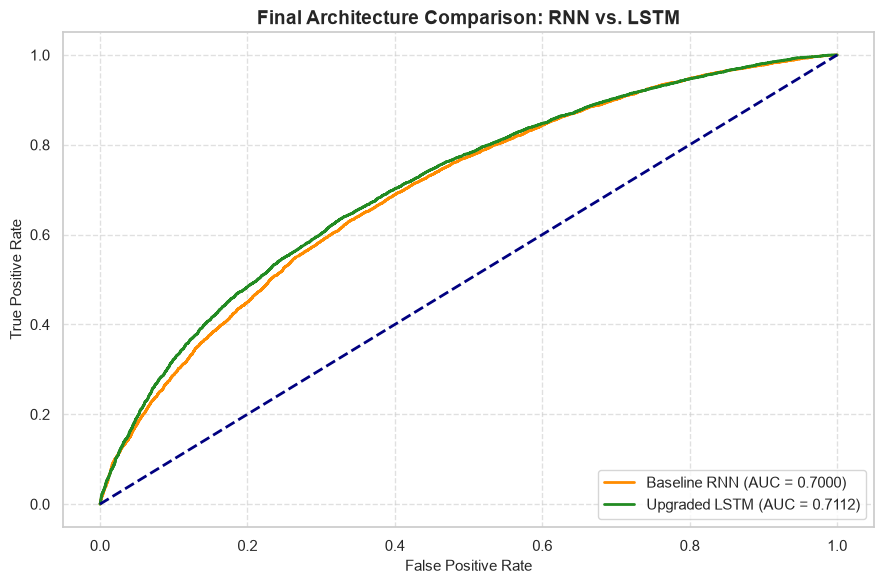

 Baseline RNN AUC :  0.7000
 Upgraded LSTM AUC:  0.7112


In [29]:
lstm_model.eval()
lstm_preds, lstm_targets = [], []

with torch.no_grad():
    for x_cat, x_cont, targets in val_loader:
        preds = lstm_model(x_cat, x_cont)
        mask = (targets != -1.0)
        if len(targets[mask]) > 0:
            lstm_preds.extend(preds[mask].cpu().numpy())
            lstm_targets.extend(targets[mask].cpu().numpy())

lstm_auc_final = roc_auc_score(lstm_targets, lstm_preds)
rnn_auc_final = roc_auc_score(best_targets, best_preds)

fpr_rnn, tpr_rnn, _ = roc_curve(best_targets, best_preds)
fpr_lstm, tpr_lstm, _ = roc_curve(lstm_targets, lstm_preds)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rnn, tpr_rnn, color='darkorange', lw=2, label=f'Baseline RNN (AUC = {rnn_auc_final:.4f})')
plt.plot(fpr_lstm, tpr_lstm, color='forestgreen', lw=2, label=f'Upgraded LSTM (AUC = {lstm_auc_final:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Final Architecture Comparison: RNN vs. LSTM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f" Baseline RNN AUC :  {rnn_auc_final:.4f}")
print(f" Upgraded LSTM AUC:  {lstm_auc_final:.4f}")

### 4.8 Mathematical Analysis of the Vanishing Gradient Problem

To understand why the baseline RNN struggles with long sequences compared to the LSTM, we must examine the mathematics of Backpropagation Through Time (BPTT). 

#### 1. The Mathematical Root of the Problem
In a standard RNN, the hidden state $h_t$ at time step $t$ is calculated using the previous hidden state $h_{t-1}$ and the current input $x_t$:
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

During training, we calculate the gradient of the loss $\mathcal{L}$ with respect to the recurrent weight matrix $W_{hh}$ to update our model. By the chain rule, the gradient at time $t$ depends on all previous time steps $k$:
$$\frac{\partial \mathcal{L}}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}_t}{\partial W_{hh}}$$

The critical failure point occurs when we calculate how a hidden state far in the past affects the current hidden state ($\frac{\partial h_t}{\partial h_k}$). This requires a continuous product of Jacobians across time:
$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}} = \prod_{j=k+1}^{t} \left( W_{hh}^T \cdot \text{diag}(f'(z_j)) \right)$$

Because the derivative of the $\tanh$ activation function, $f'(z)$, is strictly bounded between **$0$ and $1$**, and our initialized weights $W_{hh}$ are often small, multiplying these matrices together repeatedly results in exponential decay. 

#### 2. The Impact of Sequence Length (Lookback Window)
The severity of this exponential decay is directly tied to the sequence length $T$ (our lookback window size).
* If $T = 5$, the chain rule only multiplies $5$ small numbers together. The gradient survives, and the network learns short-term patterns.
* In our assignment, we used a lookback window of **$T = 50$**. Because a fraction raised to the 50th power approaches zero ($0.5^{50} \approx 0$), the gradients from the earliest questions vanish completely before they can update the weights. 

**Conclusion:** As sequence length increases, the RNN completely loses the ability to learn long-term dependencies. A student's performance on Question 1 physically cannot influence the weights for Question 50 because the mathematical gradient signal decays to zero. This necessitates the use of LSTMs, which bypass this multiplication via an additive Cell State.